# RNA velocity analysis for posterior midgut

**Purpose**

RNA velocity was used to infer developmental trajectories in the posterior midgut.

**Input**
* An AnnData object containing spliced and unspliced counts together with raw gene expression.
* A Seurat-integrated AnnData object providing cluster identities for the same cells. 
* The full dataset integrated with Harmony, used as the expression reference for Seurat integration.

**Workflow overview**

The posterior midgut subset was first extracted from the full dataset.
Seurat anchor-based integration was then performed across the posterior midgut cells.

The resulting batch-corrected gene expression matrix was merged back into the posterior midgut AnnData object, which already contained the spliced and unspliced layers from Velocyto.

To prepare the data for RNA velocity, cell cycle genes were excluded, and all genes expressed in at least three cells (≈10,000 genes) were retained.
The data were then normalized and used to compute first- and second-order moments and estimate RNA velocity and construct the velocity graph.

**Output**

A UMAP embedding showing the direction of RNA velocity flow in the posterior midgut.

**Saved file**

`PMG_6to9_allgenes_cycle.h5ad` – AnnData object containing the posterior midgut cells with calculated RNA velocity, velocity graph, and embeddings.

In [ ]:
import os
import random

import numpy as np
import pandas as pd
import scanpy as sc

import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

from scipy.sparse import csr_matrix, issparse

from scipy import io

sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (4, 4)

from scipy.sparse import csr_matrix, issparse

import anndata as ad

# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

%%R
# R packages
library(Seurat)

In [ ]:
SEED = 0

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
%%R
set.seed(0)
# R packages
library(Seurat)

In [ ]:
adata=sc.read('../data/processed/WT_Harmony.h5ad')
adata

In [ ]:
adata_velo=sc.read('../data/processed/mg_6_7_8_9_velo_refint.h5ad')
adata_velo

In [ ]:
velo_raw=sc.read('../data/processed/mg_6_7_8_9_raw_velo.h5ad')
velo_raw

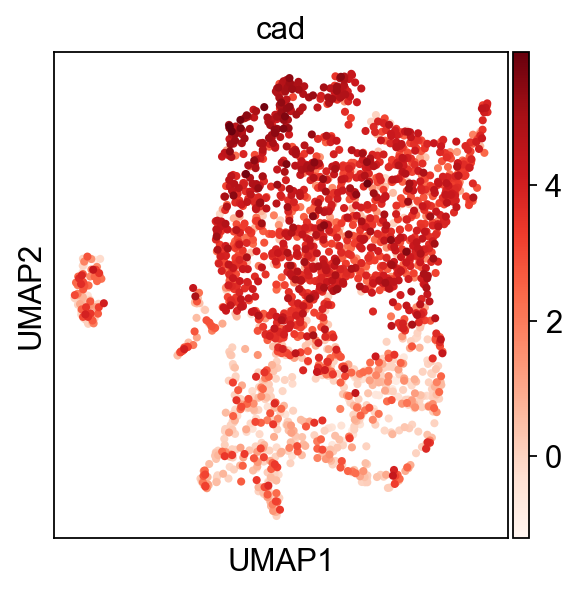

In [7]:
sc.pl.umap(adata_velo, color='cad', cmap='Reds', use_raw=False)

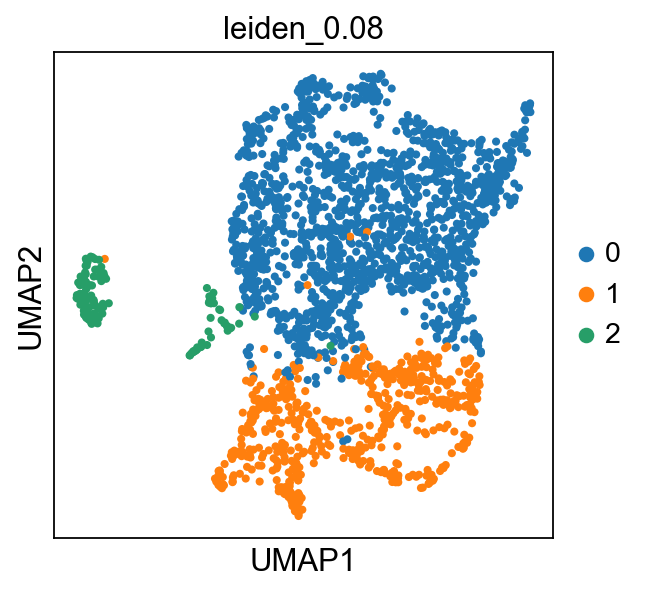

In [8]:
sc.pl.umap(adata_velo, color='leiden_0.08')

In [ ]:
velo_raw.obs['leiden_0.08'] = adata_velo.obs['leiden_0.08']

In [ ]:
velo_raw.layers['raw_counts']=velo_raw.X.copy()

In [ ]:
post_velo=velo_raw[velo_raw.obs['leiden_0.08']=='0']
post_velo

In [ ]:
g2m=pd.read_csv('../data/external/G2MMarkers.txt', header=None)

In [ ]:
sphase=pd.read_csv('../data/external/SPhaseMarkers.txt', header=None)

In [ ]:
cellcycle=pd.read_csv('../data/external/genes_cellcycle_manual.txt', header=None)

In [ ]:
post_velo=post_velo[:,~post_velo.var_names.isin(g2m[0])]

In [ ]:
post_velo=post_velo[:,~post_velo.var_names.isin(sphase[0])]

In [ ]:
post_velo=post_velo[:,~post_velo.var_names.isin(cellcycle[0])]

In [ ]:
post_velo

In [ ]:
post_seu=adata[adata.obs_names.isin(post_velo.obs_names), adata.var_names.isin(post_velo.var_names)].copy()
post_seu

In [ ]:
post_seu.X = post_seu.layers['raw_counts'].copy()
post_seu.X

In [ ]:
sc.pp.normalize_total(post_seu)
sc.pp.log1p(post_seu)

In [ ]:
post_seu.X

In [ ]:
post_seu.layers['logcounts']=post_seu.X.copy()

In [ ]:
sc.pl.umap(post_seu, color='batch')

In [ ]:
post_seu.X=post_seu.layers['raw_counts'].copy()

In [ ]:
post_seu.X

In [ ]:
post_seu

In [ ]:
# Convert categorical columns to strings
post_seu.obs['batch'] = post_seu.obs['batch'].astype(str)
#post_seu.obs['celltype'] = post_seu.obs['celltype'].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del post_seu.uns
post_seu

In [ ]:
post_seu.var

In [ ]:
%%R -i post_seu
post_seu

In [ ]:
%%R -i post_seu
seurat <- as.Seurat(post_seu, counts = "raw_counts", data = "logcounts")
seurat

In [ ]:
batch_key='batch'

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(seurat, split.by = batch_key)
batch_list

In [ ]:
%%R
anchors <- FindIntegrationAnchors(batch_list, anchor.features = rownames(seurat), dims=1:30)
anchors

In [ ]:
%%R
integrated <- IntegrateData(anchors, dims=1:30)
integrated

In [ ]:
%%R -o integrated_expr
# Extract the integrated expression matrix
integrated_expr <- GetAssayData(integrated)
# Make sure the rows and columns are in the same order as the original object
integrated_expr <- integrated_expr[rownames(seurat), colnames(seurat)]
# Transpose the matrix to AnnData format
integrated_expr <- t(integrated_expr)
print(integrated_expr[1:10, 1:10])

In [ ]:
post_seu.X = integrated_expr
post_seu.layers["seurat"] = integrated_expr
print(post_seu)

In [ ]:
post_seu.X.toarray()

In [ ]:
post_seu=post_seu[post_velo.obs_names, :]

In [ ]:
post_seu=post_seu[:,post_velo.var_names]

In [ ]:
post_velo.layers['seurat']=post_seu.layers['seurat']

In [ ]:
post_velo.X=post_velo.layers['seurat'].copy()
post_velo.X.toarray()

In [ ]:
sc.pp.pca(post_velo)

In [ ]:
sc.pp.neighbors(post_velo,n_pcs=25, n_neighbors=12)
sc.tl.umap(post_velo, n_components=2)
sc.pl.umap(post_velo, color=[ batch_key])

In [ ]:
sc.pp.neighbors(post_velo,n_pcs=25, n_neighbors=12)
sc.tl.umap(post_velo, n_components=2)
sc.pl.umap(post_velo, color=['celltype', batch_key], wspace=1, )

In [ ]:
sc.pl.umap(post_velo, color=['celltype_2', batch_key], wspace=1, )

In [ ]:
theta = np.radians(150)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array(((c, -s), (s, c)))

# Apply the rotation matrix to the UMAP coordinates
post_velo.obsm['X_umap_rotated'] = np.dot(post_velo.obsm['X_umap'], rotation_matrix)

In [ ]:
sc.pl.embedding(post_velo, color='celltype_2', basis='X_umap_rotated')

In [ ]:
post_velo.obsm['X_umap']=post_velo.obsm['X_umap_rotated']

In [ ]:
sc.pl.umap(post_velo, color='celltype_2')

In [ ]:
post_velo.X=post_velo.layers['raw_counts'].copy()

In [ ]:
post_velo

In [ ]:
scv.pp.filter_and_normalize(
    post_velo, n_top_genes=10000, subset_highly_variable=False
)

In [ ]:
post_velo.X

In [ ]:
post_velo.layers['spliced'].toarray()

In [ ]:
sc.pp.log1p(post_velo)
post_velo.X

In [ ]:
scv.pp.moments(post_velo, n_pcs=None, n_neighbors=None, use_highly_variable=False)

In [ ]:
scv.tl.recover_dynamics(post_velo, n_jobs=8)

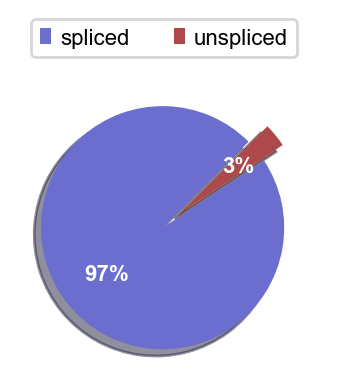

In [66]:
scv.pl.proportions(post_velo)

In [ ]:
scv.tl.velocity(post_velo, mode='dynamical')


In [ ]:
scv.tl.velocity_graph(post_velo)

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


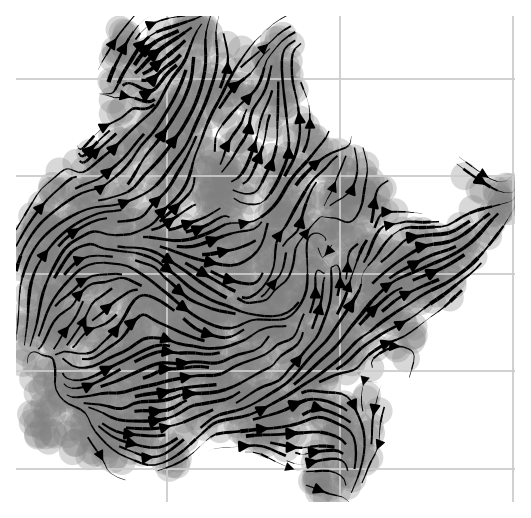

In [69]:
scv.pl.velocity_embedding_stream(post_velo, show=False, recompute=True)
plt.savefig("../figures/RNA_velocity.pdf", dpi=300, bbox_inches='tight')

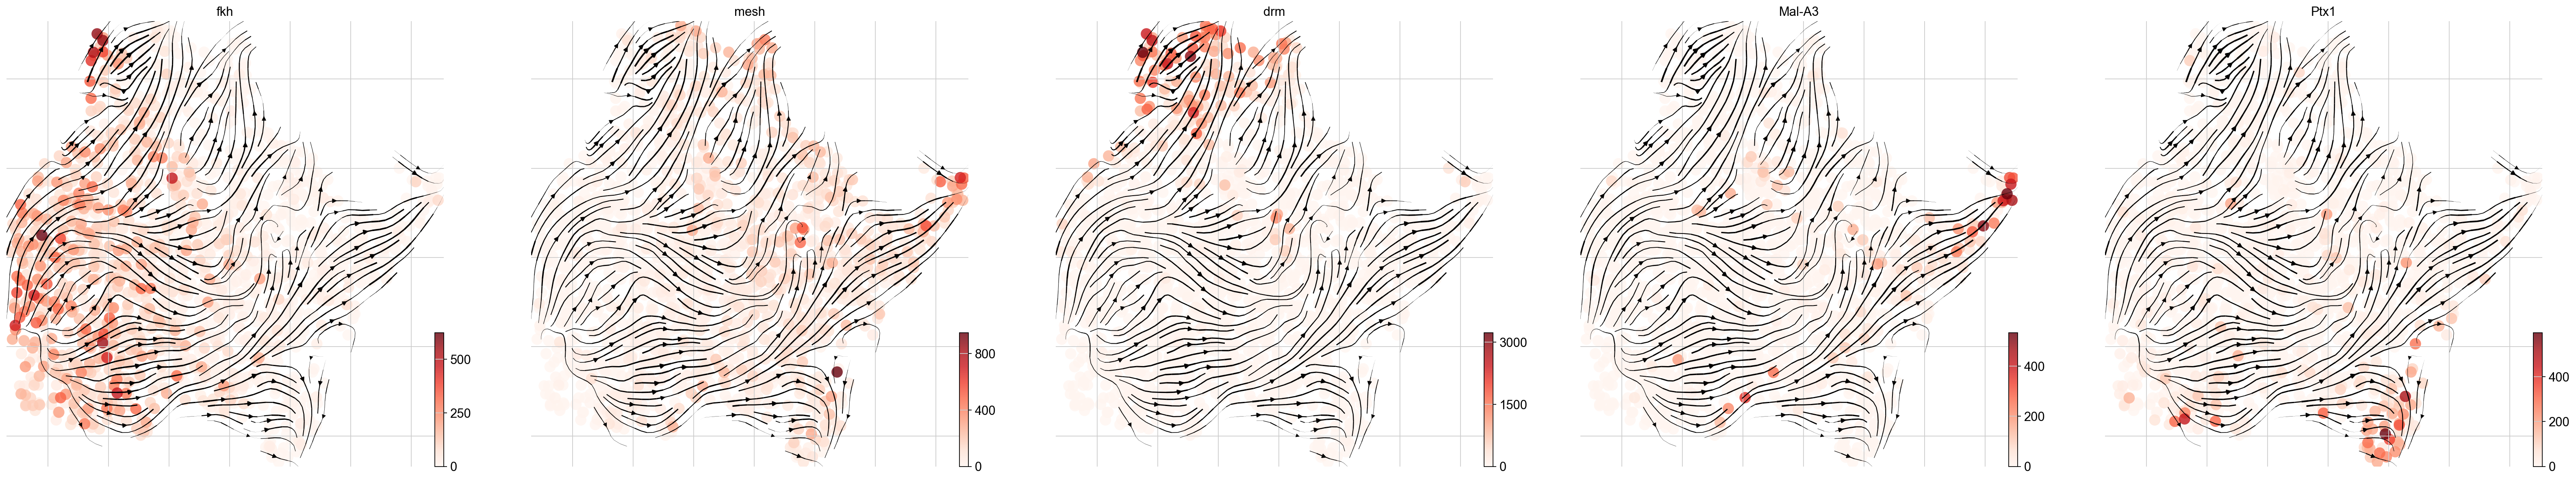

In [70]:
scv.pl.velocity_embedding_stream(post_velo, color=['fkh', 'mesh', 'drm', 'Mal-A3', 'Ptx1'], cmap='Reds', figsize=[10,9], alpha=0.8, show=False)
plt.savefig("../figures/RNA_velocity_genes.pdf", dpi=300, bbox_inches='tight')

In [ ]:
post_velo.write('../data/processed/PMG_6to9_allgenes_cycle.h5ad')